# Lesson 0003: ice, water, steam, a first classifier

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tamnd/soroban/blob/main/lessons/0003-classification/lesson.ipynb)

This notebook is the runnable half of lesson 0003. The full writeup, with every step of the hand arithmetic, is in the [lesson README](https://github.com/tamnd/soroban/tree/main/lessons/0003-classification). Same contract as always: you have computed a training run on paper, and the code below has to agree with your paper, with an `assert` guarding every important number.

The question changes this lesson, from "how much" to "which one". Six points on a temperature-like line belong to three classes, ice, water, or steam, and the model gives each class its own score line, turns the scores into probabilities with [softmax](https://github.com/tamnd/soroban/blob/main/maths/softmax.md), and pays [cross-entropy](https://github.com/tamnd/soroban/blob/main/maths/cross-entropy.md) on the probability it gave the truth:

$$z_k = w_k x + b_k \qquad p_k = \frac{e^{z_k}}{\sum_j e^{z_j}} \qquad L = \mathrm{mean}(-\ln p_{\text{true}})$$

Here is the whole notebook in one animation, rendered with manim from this lesson's `visuals.py`: three probability curves that start flat at one third each and learn to carve the line into territories.

![the three probability curves learning](https://raw.githubusercontent.com/tamnd/soroban/main/lessons/0003-classification/assets/fit.gif)

## 0. Softmax, worked by calculator

Softmax [exponentiates](https://github.com/tamnd/soroban/blob/main/maths/exp-log.md) every score, making them positive while keeping their order, then divides by the total so they sum to 1. The cell below reproduces the README's worked example on the scores $(2, 0, -2)$, and checks softmax's key property, shift invariance: only the gaps between scores matter, so adding a constant to all of them changes nothing. That property is also the standard defense against overflow (subtract the max score first), which this lesson gets to break on purpose later.

In [1]:
import math

import numpy as np

def softmax_rows(Z):
    Z = np.atleast_2d(Z)
    ez = np.exp(Z - Z.max(axis=1, keepdims=True))  # subtract-max: the survival habit
    return ez / ez.sum(axis=1, keepdims=True)

z = np.array([2.0, 0.0, -2.0])
p = softmax_rows(z)[0]
print("e^z:", np.exp(z))
print("p:  ", p, "  sum:", p.sum())
assert np.abs(p - [0.866813, 0.117310, 0.015876]).max() < 1e-6
assert np.allclose(softmax_rows(z + 100.0)[0], p, atol=1e-15)  # shift invariance
print("a lead of 2 in score is a lead of e^2 =", f"{np.exp(2):.2f}", "times in probability")

e^z: [7.3890561  1.         0.13533528]
p:   [0.86681333 0.11731043 0.01587624]   sum: 0.9999999999999999
a lead of 2 in score is a lead of e^2 = 7.39 times in probability


## 1. Cross-entropy, the price of a probability

The loss charges $-\ln(p_{\text{true}})$ per point: free when certain and right, ruinous when certain and wrong, and $\ln 3 = 1.0986$ for a three-class model that knows nothing.

![the price of a probability](https://raw.githubusercontent.com/tamnd/soroban/main/lessons/0003-classification/assets/price.png)

One identity makes the worked example hand-checkable: $-\ln p_k = \ln(\text{sum of } e^z) - z_k$, so on the scores $(2, 0, -2)$ the three possible costs sit exactly 2 apart, the same as the score gaps.

In [2]:
costs = -np.log(p)
print("cost if the truth were each class:", costs)
assert np.abs(costs - [0.142932, 2.142932, 4.142932]).max() < 1e-6
assert abs((costs[1] - costs[0]) - 2) < 1e-12 and abs((costs[2] - costs[1]) - 2) < 1e-12

for prob in (1.0, 0.9, 0.5, 1/3, 0.01):
    cost = -math.log(prob) + 0.0  # + 0.0 turns IEEE's -0.0 into a plain 0
    print(f"p = {prob:<5.4g} costs {cost:.6f}")

cost if the truth were each class: [0.14293163 2.14293163 4.14293163]
p = 1     costs 0.000000
p = 0.9   costs 0.105361
p = 0.5   costs 0.693147
p = 0.3333 costs 1.098612
p = 0.01  costs 4.605170


## 2. Step 1 by hand: probability minus target

The data, and the zero init. Zero init was a corpse in lesson 0002 (interchangeable neurons stay clones), but here the three rows are told apart by their targets, so it is safe, and it makes step 1 the cleanest in the repo: every score 0, every probability exactly 1/3, loss exactly $\ln 3$.

The backward pass collapses into the star formula of the lesson: $\partial L / \partial z_k = p_k - y_k$, probability minus [one-hot](https://github.com/tamnd/soroban/blob/main/maths/notation.md) target, and from there the lesson 0001 pattern (times $x$ for the weight, times 1 for the bias) gives $dw = (1/2, 0, -1/2)$ and $db = (0, 0, 0)$.

One regime change, courtesy of the [floats page](https://github.com/tamnd/soroban/blob/main/maths/floats.md): thirds and $\ln 3$ are not binary-exact, so for the first time even step 1 asserts with a tolerance, 1e-12, rather than `==`.

In [3]:
x = np.array([-2.0, -1.0, -0.5, 0.5, 1.0, 2.0])
labels = np.array([0, 0, 1, 1, 2, 2])  # ice, ice, water, water, steam, steam
N = len(x)
Y = np.eye(3)[labels]  # one-hot targets

w = np.zeros(3)
b = np.zeros(3)

P = softmax_rows(np.outer(x, w) + b)
loss = -np.log(P[np.arange(N), labels]).mean()
print("every probability:", P[0], " loss:", loss, "= ln 3")
assert abs(loss - math.log(3)) < 1e-12

dZ = (P - Y) / N          # probability minus target, averaged
dw = (dZ * x[:, None]).sum(axis=0)
db = dZ.sum(axis=0)
print("dw:", dw, "  db:", db)
assert np.abs(dw - [0.5, 0.0, -0.5]).max() < 1e-12
assert np.abs(db).max() < 1e-12

# two checks that come free with any softmax classifier: within each point
# the dz values sum to 0, so the gradients must sum to 0 across classes
assert abs(dw.sum()) < 1e-15 and abs(db.sum()) < 1e-15
print("both gradient triples sum to zero, as the paper says they must")

every probability: [0.33333333 0.33333333 0.33333333]  loss: 1.0986122886681098 = ln 3
dw: [ 0.5  0.  -0.5]   db: [-2.77555756e-17 -2.77555756e-17 -2.77555756e-17]
both gradient triples sum to zero, as the paper says they must


## 3. The training loop

lr = 0.1, 300 steps, asserts pinning the first three losses to the hand run. Two things to watch that never happened in lessons 0001 and 0002. First, from step 103 the model classifies all six points correctly and never misses again, yet the loss keeps falling: on separated data cross-entropy never reaches zero, it only widens the score gaps forever. Second, the final knobs: ice and steam end as exact mirror images, and water's weight is exactly zero, not small, zero, because water's points are mirror twins and their pulls on $w_1$ cancel at every single step. Water is not a direction on this axis, it is a home between the other two, and it learns only through its bias.

In [4]:
w = np.zeros(3)
b = np.zeros(3)
lr = 0.1
losses = []
first_all_correct = None

for step in range(1, 301):
    P = softmax_rows(np.outer(x, w) + b)
    loss = -np.log(P[np.arange(N), labels]).mean()
    losses.append(loss)

    if first_all_correct is None and (P.argmax(axis=1) == labels).all():
        first_all_correct = step

    if step == 1:
        assert abs(loss - math.log(3)) < 1e-12
    if step == 2:
        assert abs(loss - 1.0500696359446569) < 1e-9
    if step == 3:
        assert abs(loss - 1.0070093819902546) < 1e-9

    if step in (1, 2, 3, 10, 50, 300):
        print(f"step {step:3d}  loss {loss:.9f}")

    dZ = (P - Y) / N
    w = w - lr * (dZ * x[:, None]).sum(axis=0)
    b = b - lr * dZ.sum(axis=0)

print(f"final     w ({w[0]:.6f}, {w[1]:.6f}, {w[2]:.6f})"
      f"  b ({b[0]:.6f}, {b[1]:.6f}, {b[2]:.6f})")
print("all six classified correctly from step", first_all_correct)
assert first_all_correct == 103
assert abs(w[0] + w[2]) < 1e-9 and abs(b[0] - b[2]) < 1e-9  # mirror images
assert abs(w[1]) < 1e-12  # water's weight: exactly the zero it started as

step   1  loss 1.098612289
step   2  loss 1.050069636
step   3  loss 1.007009382
step  10  loss 0.810954377
step  50  loss 0.540872971
step 300  loss 0.317192583
final     w (-2.448889, 0.000000, 2.448889)  b (-0.553134, 1.106268, -0.553134)
all six classified correctly from step 103


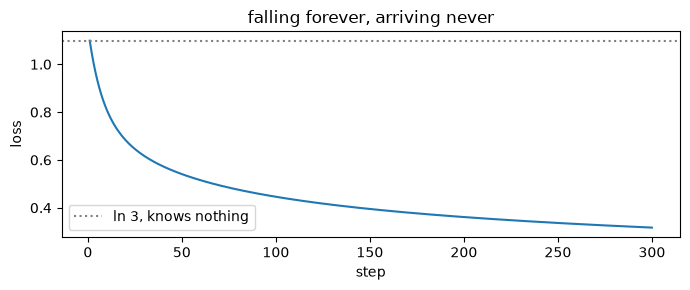

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3))
plt.plot(range(1, 301), losses)
plt.axhline(math.log(3), color="grey", ls=":", label="ln 3, knows nothing")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("falling forever, arriving never")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Torch fuses the whole head into one call

`torch.nn.functional.cross_entropy` takes raw scores and does softmax plus the log loss in one function, with the subtract-max trick and the paper's cancellation built in. It is what every real training loop calls. The cell asserts torch's [autodiff](https://github.com/tamnd/soroban/blob/main/maths/autodiff.md) against your six hand gradients at 1e-12.

In [6]:
try:
    import torch

    xt = torch.tensor([-2.0, -1.0, -0.5, 0.5, 1.0, 2.0], dtype=torch.float64)
    lt = torch.tensor([0, 0, 1, 1, 2, 2])
    wt = torch.zeros(3, dtype=torch.float64, requires_grad=True)
    bt = torch.zeros(3, dtype=torch.float64, requires_grad=True)

    tloss = torch.nn.functional.cross_entropy(xt[:, None] * wt + bt, lt)
    tloss.backward()

    print("torch: loss", tloss.item(), " dw", wt.grad.tolist(), " db", bt.grad.tolist())
    assert abs(tloss.item() - math.log(3)) < 1e-12
    assert all(abs(g - e) < 1e-12 for g, e in zip(wt.grad.tolist(), [0.5, 0.0, -0.5]))
    assert all(abs(g) < 1e-12 for g in bt.grad.tolist())
    print("torch agrees with your paper, loss and all six gradients")
except ImportError:
    print("torch not installed, skipping this check (Colab has it preinstalled)")

torch: loss 1.0986122886681098  dw [0.5, 0.0, -0.5]  db [0.0, 0.0, 0.0]
torch agrees with your paper, loss and all six gradients


## 5. Break it on purpose

The learning-rate ladder is missing its top rung this lesson. Cross-entropy's gradient is probability minus target, bounded by 1 no matter how wrong the model is, so there is no MSE-style explosion: lr = 25 thrashes for a few steps and then lands anyway. The crash that remains is numerical. At lr = 1000 the scores reach the hundreds, a naive softmax (no subtract-max) computes $e^{500} = $ `inf`, then `inf/inf` = `nan`, and the run is dead by step 2, while the subtract-max version finishes the same run untouched.

In [7]:
def run(lr_try, steps, naive=False):
    w, b = np.zeros(3), np.zeros(3)
    out = []
    for _ in range(steps):
        Z = np.outer(x, w) + b
        if naive:
            ez = np.exp(Z)                       # no subtract-max: lives dangerously
            P = ez / ez.sum(axis=1, keepdims=True)
        else:
            P = softmax_rows(Z)
        out.append(-np.log(P[np.arange(N), labels]).mean())
        dZ = (P - Y) / N
        w = w - lr_try * (dZ * x[:, None]).sum(axis=0)
        b = b - lr_try * dZ.sum(axis=0)
    return out

for lr_try in (0.1, 1.0, 5.0, 25.0):
    ls = run(lr_try, 100)
    row = "  ".join(f"{l:8.4f}" for l in ls[:5])
    print(f"lr {lr_try:6}:  {row}   step 100: {ls[99]:.4f}")

with np.errstate(over="ignore", invalid="ignore"):
    naive_ls = run(1000.0, 5, naive=True)
    safe_ls = run(1000.0, 300)
print("naive at lr 1000: ", "  ".join(f"{l:.4f}" for l in naive_ls))
print(f"safe  at lr 1000 reaches step 300 with loss {safe_ls[-1]:.9f}")
assert np.isnan(naive_ls[1])            # dead by step 2
assert np.isfinite(safe_ls).all()       # subtract-max survives the same run
assert run(25.0, 100)[99] < 0.01        # huge lr converges anyway: bounded gradients

lr    0.1:    1.0986    1.0501    1.0070    0.9688    0.9347   step 100: 0.4461
lr    1.0:    1.0986    0.7357    0.6366    0.5843    0.5480   step 100: 0.2014
lr    5.0:    1.0986    0.5519    0.3300    0.3085    0.2926   step 100: 0.0693
lr   25.0:    1.0986    2.0840    0.7255    1.8867    0.6564   step 100: 0.0032
naive at lr 1000:  1.0986  nan  nan  nan  nan
safe  at lr 1000 reaches step 300 with loss -0.000000000


That printed -0.000000000 from the safe run is two floats lessons at once: the true loss is never zero, but the gaps are so wide that the true class's probability rounds to exactly 1.0 in float64, and the stray minus sign is $-\ln(1.0)$ landing on IEEE's negative zero, a float equal to zero that remembers the sign of the operation that made it. A printed zero is a claim about the printer.

One more comparison, the reason the loss is cross-entropy and not MSE on the probabilities. On a confident-wrong point, MSE's gradient carries a factor of the softmax slope, which is nearly flat where probabilities pin to 0 or 1, so the points the model most needs to fix are the ones it pushes weakest. Cross-entropy's log cancels that flatness exactly.

In [8]:
z_cw = np.array([6.0, 0.0, -6.0])   # confident and wrong: the truth is class 2
y_cw = np.array([0.0, 0.0, 1.0])
p_cw = softmax_rows(z_cw)[0]

ce_push = p_cw - y_cw                                 # cross-entropy's dL/dz
J = np.diag(p_cw) - np.outer(p_cw, p_cw)              # softmax's slope matrix
mse_push = J.T @ (2 * (p_cw - y_cw))                  # MSE-on-probabilities' dL/dz

print("p:", p_cw)
print("cross-entropy's push on the true score:", ce_push[2])
print("MSE's push on the true score:          ", mse_push[2])
print(f"cross-entropy pushes {abs(ce_push[2] / mse_push[2]):,.0f} times harder")
assert abs(ce_push[2]) > 0.9999
assert abs(ce_push[2] / mse_push[2]) > 40000

p: [9.97521263e-01 2.47260800e-03 6.12898247e-06]
cross-entropy's push on the true score: -0.9999938710175331
MSE's push on the true score:           -2.445516132564013e-05
cross-entropy pushes 40,891 times harder


## 6. What the model believes between and beyond the data

Ask the trained model for probabilities where the data was silent. Halfway between an ice point and a water point it is honestly torn, which is softmax working as intended. Far past the data it is certain, which is not knowledge: the score lines extrapolate forever, the gaps grow, and softmax converts any big gap into certainty. Same standing as lesson 0002's flat valley, geometry where the data never spoke.

![the trained probability curves](https://raw.githubusercontent.com/tamnd/soroban/main/lessons/0003-classification/assets/curves.png)

p at x = -0.75:  ice 0.537  water 0.450  steam 0.014
p at x =   0.0:  ice 0.138  water 0.724  steam 0.138
p at x =  10.0:  ice 0.000  water 0.000  steam 1.000


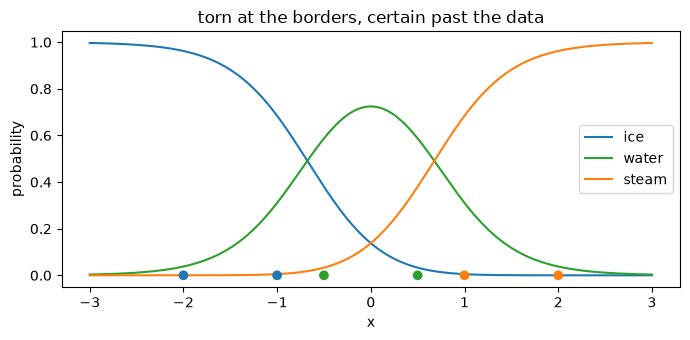

In [9]:
def predict_probs(q):
    return softmax_rows(w * q + b)[0]

for q in (-0.75, 0.0, 10.0):
    pq = predict_probs(q)
    print(f"p at x = {q:5}:  ice {pq[0]:.3f}  water {pq[1]:.3f}  steam {pq[2]:.3f}")
assert abs(predict_probs(-0.75)[0] - 0.537) < 1e-3   # torn between ice and water
assert predict_probs(10.0)[2] > 0.999999             # certain, past all its data

grid = np.linspace(-3, 3, 601)
curves = np.array([predict_probs(q) for q in grid])
plt.figure(figsize=(7, 3.5))
for k, (name, color) in enumerate([("ice", "tab:blue"), ("water", "tab:green"), ("steam", "tab:orange")]):
    plt.plot(grid, curves[:, k], color=color, label=name)
plt.scatter(x, np.zeros(N), c=[["tab:blue", "tab:green", "tab:orange"][k] for k in labels], zorder=3)
plt.xlabel("x")
plt.ylabel("probability")
plt.title("torn at the borders, certain past the data")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Exercises

1. Before running anything: what is the largest gradient any weight could ever feel in this lesson, at any parameter values? Then explain the lr = 25 row above.
2. Relabel the last point water (classes ice, ice, water, water, steam, water) and predict all six step-1 gradients before verifying with the cells above. Which way does the model's first instinct push the common class?
3. Delete the $x = 0.5$ water point and retrain. The symmetry argument said water's weight stays zero forever; predict what it does now, and what the model answers at the deleted point.

Answers and discussion are at the end of the [lesson README](https://github.com/tamnd/soroban/tree/main/lessons/0003-classification), along with the exit test: four fresh points with unequal class counts (the bias gradients wake up), to train by hand and check yourself against. When your paper and your asserts agree, you are done. Lesson 0004 retires the hand backward pass: you build the autograd engine that does it forever after.